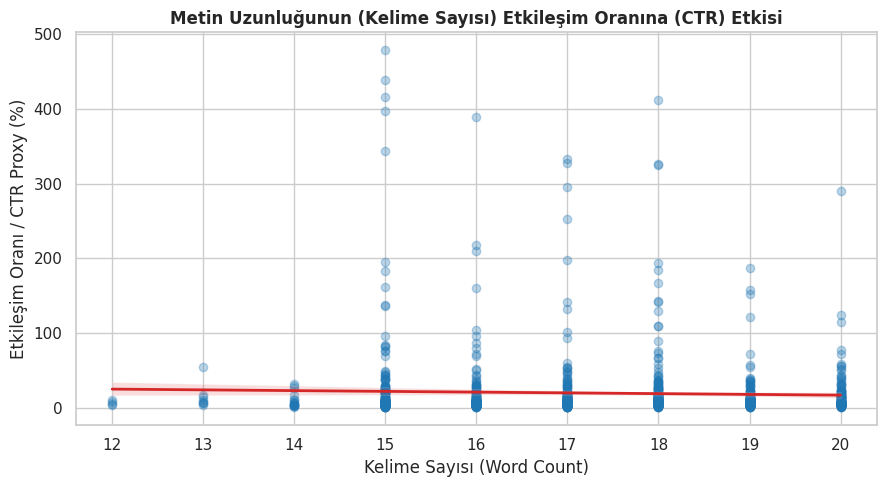

/tmp/ipykernel_8986/3652575230.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=features_summary, x='Öznitelik', y='Ortalama CTR (%)', palette='Blues_r')


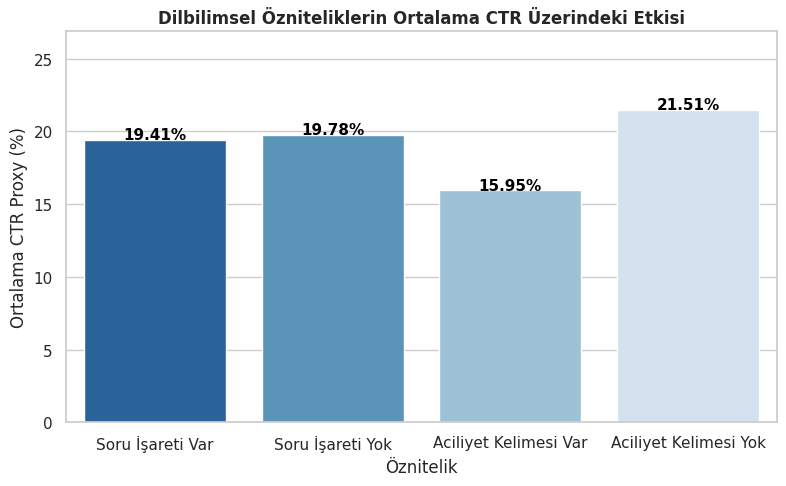

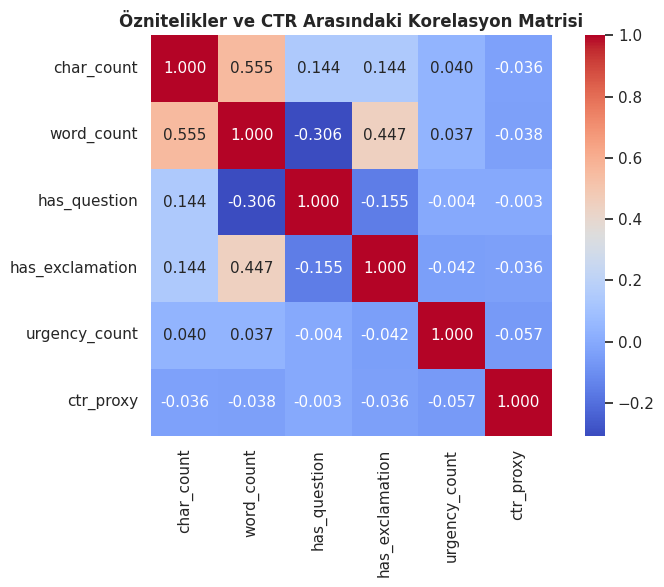

=== RAPORA EKLENECEK TEMEL SAYISAL BULGULAR ===
İncelenen Toplam İngilizce Metin Sayısı: 1185
Ortalama CTR: 19.71% (Medyan: 7.89%)
Ortalama Kelime Sayısı: 17.2


In [3]:
# ==========================================
# 1. Kütüphaneler ve Ortam Kurulumu
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Grafik stil ayarları
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

# ==========================================
# 2. Veri Yükleme ve Ön İşleme
# ==========================================
# Kaggle'dan indirdiğin CSV dosyasını Colab'e yükle
df = pd.read_csv('Social Media Engagement Dataset.csv')

# 1. Adım: Yalnızca İngilizce metinleri filtrele
df = df[df['language'] == 'en'].copy()

# 2. Adım: Hatalı/sıfır gösterim kayıtlarını temizle
df = df[df['impressions'] > 0].copy()

# 3. Adım: Hedef Metrik (Engagement Rate / Proxy CTR) Türetme
# Hata düzeltme: 'likes_count', 'shares_count' ve 'comments_count' kullanıldı.
df['ctr_proxy'] = ((df['likes_count'] + df['shares_count'] + df['comments_count']) / df['impressions']) * 100

# Aşırı uç değerleri (outliers) %99 persentilde kırp (grafik okunabilirliği için)
upper_limit = df['ctr_proxy'].quantile(0.99)
df_clean = df[df['ctr_proxy'] <= upper_limit].copy()

# ==========================================
# 3. Öznitelik Mühendisliği (NLP Features)
# ==========================================
# Metin yapısal özellikleri
df_clean['char_count'] = df_clean['text_content'].apply(lambda x: len(str(x)))
df_clean['word_count'] = df_clean['text_content'].apply(lambda x: len(str(x).split()))

# Dilbilgisi ve noktalama kalıpları
df_clean['has_question'] = df_clean['text_content'].apply(lambda x: 1 if '?' in str(x) else 0)
df_clean['has_exclamation'] = df_clean['text_content'].apply(lambda x: 1 if '!' in str(x) else 0)

# Aciliyet (Urgency) ve Satış Belirteçleri
urgency_keywords = ['now', 'today', 'limited', 'hurry', 'exclusive', 'last chance', 'deal', 'promo', 'discount', 'must have']
urgency_pattern = r'\b(' + '|'.join(urgency_keywords) + r')\b'
df_clean['urgency_count'] = df_clean['text_content'].apply(
    lambda x: len(re.findall(urgency_pattern, str(x), flags=re.IGNORECASE))
)
df_clean['has_urgency'] = df_clean['urgency_count'].apply(lambda x: 1 if x > 0 else 0)

# ==========================================
# 4. Grafikleri Üretme ve Kaydetme
# ==========================================

# GRAFİK 1: Metin Uzunluğu vs. CTR Dağılımı
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_clean,
    x='word_count',
    y='ctr_proxy',
    scatter_kws={'alpha': 0.3, 'color': '#1f77b4'},
    line_kws={'color': '#d62728', 'linewidth': 2}
)
plt.title('Metin Uzunluğunun (Kelime Sayısı) Etkileşim Oranına (CTR) Etkisi', weight='bold')
plt.xlabel('Kelime Sayısı (Word Count)')
plt.ylabel('Etkileşim Oranı / CTR Proxy (%)')
plt.tight_layout()
plt.savefig('eda_plot1_word_count_vs_ctr.png', dpi=300)
plt.show()

# GRAFİK 2: Dilbilimsel Özniteliklerin CTR Farkı
features_summary = pd.DataFrame({
    'Öznitelik': ['Soru İşareti Var', 'Soru İşareti Yok', 'Aciliyet Kelimesi Var', 'Aciliyet Kelimesi Yok'],
    'Ortalama CTR (%)': [
        df_clean[df_clean['has_question'] == 1]['ctr_proxy'].mean(),
        df_clean[df_clean['has_question'] == 0]['ctr_proxy'].mean(),
        df_clean[df_clean['has_urgency'] == 1]['ctr_proxy'].mean(),
        df_clean[df_clean['has_urgency'] == 0]['ctr_proxy'].mean()
    ]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=features_summary, x='Öznitelik', y='Ortalama CTR (%)', palette='Blues_r')
plt.title('Dilbilimsel Özniteliklerin Ortalama CTR Üzerindeki Etkisi', weight='bold')
plt.ylabel('Ortalama CTR Proxy (%)')
plt.ylim(0, features_summary['Ortalama CTR (%)'].max() * 1.25)
for index, row in features_summary.iterrows():
    plt.text(index, row['Ortalama CTR (%)'] + 0.05, f"{row['Ortalama CTR (%)']:.2f}%", color='black', ha="center", weight='bold')
plt.tight_layout()
plt.savefig('eda_plot2_feature_impact.png', dpi=300)
plt.show()

# GRAFİK 3: Öznitelik Korelasyon Isı Haritası
corr_cols = ['char_count', 'word_count', 'has_question', 'has_exclamation', 'urgency_count', 'ctr_proxy']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', cbar=True, square=True)
plt.title('Öznitelikler ve CTR Arasındaki Korelasyon Matrisi', weight='bold')
plt.tight_layout()
plt.savefig('eda_plot3_correlation_heatmap.png', dpi=300)
plt.show()

# ==========================================
# 5. Rapor İçin Betimsel İstatistik Özeti
# ==========================================
print("=== RAPORA EKLENECEK TEMEL SAYISAL BULGULAR ===")
print(f"İncelenen Toplam İngilizce Metin Sayısı: {len(df_clean)}")
print(f"Ortalama CTR: {df_clean['ctr_proxy'].mean():.2f}% (Medyan: {df_clean['ctr_proxy'].median():.2f}%)")
print(f"Ortalama Kelime Sayısı: {df_clean['word_count'].mean():.1f}")

In [2]:
print("Mevcut Sütunlar:", df.columns.tolist())
# Sütun isimlerini kontrol ettikten sonra hesaplamayı güncelleyelim
# Eğer sütunlar 'engagement_metrics_likes' formatındaysa kodu ona göre revize edeceğiz.

Mevcut Sütunlar: ['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id', 'location', 'language', 'text_content', 'hashtags', 'mentions', 'keywords', 'topic_category', 'sentiment_score', 'sentiment_label', 'emotion_type', 'toxicity_score', 'likes_count', 'shares_count', 'comments_count', 'impressions', 'engagement_rate', 'brand_name', 'product_name', 'campaign_name', 'campaign_phase', 'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate']


Yukarıdaki hücreyi çalıştırıp sütun isimlerini gördükten sonra, `df['ctr_proxy']` hesaplamasını doğru sütun isimleriyle (`likes`, `shares`, `comments` vb.) güncelleyerek EDA akışına devam edebiliriz.